# Data Loading and Inspection

Run the code cells in this first section to load the Ames Housing dataset and inspect it. Take some time to explore the outputs of these cells to get a sense of what information the dataset contains. Look out for column names, data types, sample values, and some summary statistics which will be needed later in this assignment. Note: This version of the Ames Housing dataset has already been split into training and test sets for predictive modeling. You will only be working with the training set stored in train.csv in this assignment. A description of each column in the dataset can be found in the "data_description.txt" file.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress excessive warning messages
import warnings
warnings.filterwarnings("ignore")

# Read data
train = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [2]:
# Checkout out first few rows
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Checkout out dataframe info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# Describe the dataframe including non-numeric columns
train.describe(include = "all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


## Target Distribution

1. Identify the name of the target column and store it in the "target" variable below. This should be the column that contains the sale price of the property. Note: This is meant to simplify the feature selection process since there are a large number of potential feature columns in the dataset.

In [5]:
# Define the target column
target = "SalePrice"

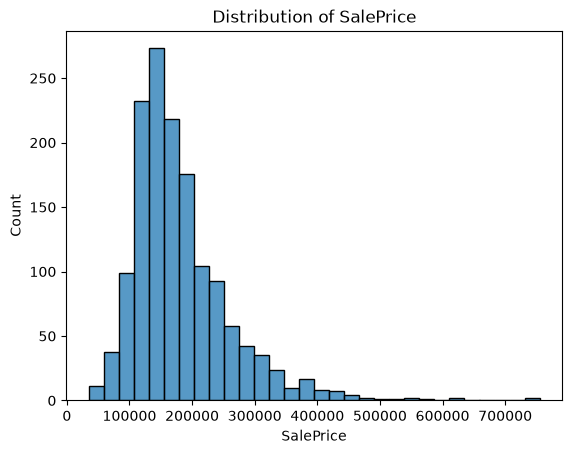

In [6]:
# Visualize the dataset, starting with the target distribution
sns.histplot(x = target, bins = 30, data = train)
plt.title(f"Distribution of {target}")
plt.show()

# Data Quality and Cleaning

In this section, you will inspect the data for quality issues and peform some minor cleaning. Using pandas dataframe attributes and methods, complete the actions requested in the markdown cells.

You have likely noticed that there are far more columns in this dataset compared to the previous activity. Although this complicates the EDA process somewhat, many of the data quality checks are still the same. These include using appropriate data types, checking for duplicate rows, and identifying columns with missing values.

2. Use appropriate methods to count the number of duplicate rows in the dataset. There shouldn't be any duplicate rows.

In [7]:
# Verify that there are no duplicate rows in the dataset
train.duplicated().sum()

np.int64(0)

3. Use appropriate methods to determine the total number or the proportion of missing values in each column and store the result in "missing" below. This time, sort the resulting values in descending order so that the columns with the most missing values appear at the top. Keep an eye out for columns with a large number of missing values.

In [8]:
# Count the number of missing values or the proportion of 
# missing values in each column using an appropriate method
missing = train.isnull().mean()   
missing[missing > 0].sort_values(ascending=False)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
GarageQual      0.055479
GarageCond      0.055479
BsmtExposure    0.026027
BsmtFinType2    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64

You may have noticed that many of the columns with missing values are categorical features related to the property's garage or basement. If you refer to the information in data_description.txt, you'll find that "NA" has been used as a placeholder for "No garage" or "No basement" in these columns respectively. Therefore, these are not truly missing values and they can safely be replaced by an appropriate category. 

4. The steps to fill the missing values in the garage columns is shown in the next code cell. Complete the code in the following code cell to fill missing values in basement columns (i.e., those starting with "Bsmt") with "No basement". Then examine the number/proportion of missing values in each column again to identify which columns are still missing values.

In [9]:
# Fill missing values for garage-related columns with "No garage"
garage_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"] # No garage
train[garage_cols] = train[garage_cols].fillna("No garage")

In [10]:
# Fill missing values for basement-related columns with "No basement"
basement_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"] # No basement
train[basement_cols] = train[basement_cols].fillna("No basement")

In [11]:
# Count the number of missing values or the proportion of 
# missing values in each column using an appropriate method
missing = train.isnull().mean()
missing[missing > 0].sort_values(ascending=False)

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
FireplaceQu    0.472603
LotFrontage    0.177397
GarageYrBlt    0.055479
MasVnrArea     0.005479
Electrical     0.000685
dtype: float64

Columns with a high proportion of missing values (>40%) typically make for poor features. Unless you can reliably determine an appropriate replacement value, they should not be used as features.

Note: In general, there isn't a strict cut-off for what proportion of missing values makes a feature worth dropping. As you saw previously, missing values in this dataset typically represent the absence of a feature and could be inferred. When this isn't the case, you can either choose to drop the columns or impute them using statistical methods (i.e., using mean, median, mode, etc.). Imputing missing values must be done carefully so that only information from the training dataset is used to determine replacement values and avoid data "leakage" (more on this topic later). For the purpose of simplifying feature selection in this assignment and because many of these features are redundant, you will elect to drop columns with high proportions of missing values.

5. Based on your results from the previous code cell, identify all features with more than 40% missing values and add their names to the "drop_cols" list in the next code cell. You don't need to drop the columns now, the idea here is to keep track of columns that have poor predictive power in a list to facilitate feature selection later.

In [12]:
# Select all features to drop based on a high number (>40%) of missing values
drop_cols = missing[missing > 0.4].index.to_list()
print(drop_cols)

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


Ensure that all columns have proper data types. Pandas likely detected most of the numeric data types correctly, but any columns containing text are likely using the generic "object" data type.

Note: This step was purposely moved after filling in missing categorical values because the "fillna" method won't work on columns with type "category" unless the replacement value is explicitly added as a new category first. It is simpler to cast these columns as "category" types after missing values are handled.

6. Select all columns with the "object" data type and convert them to the "category" data type.

In [13]:
# Convert "object" columns to category data type to save memory and 
# improve performance
cat_cols = train.select_dtypes(include="object").columns.to_list()
train[cat_cols] = train[cat_cols].astype("category")

7. Use an appropriate attribute to display the data types for each column.

In [14]:
# Check data types after conversion
train.dtypes

Id                  int64
MSSubClass          int64
MSZoning         category
LotFrontage       float64
LotArea             int64
                   ...   
MoSold              int64
YrSold              int64
SaleType         category
SaleCondition    category
SalePrice           int64
Length: 81, dtype: object

# EDA

In this section, EDA will be applied to identify strong features to use for a regression model and identify weak features for removal. In regression problems, strong features often show a clear relationship with the target variable, either through correlation, differences between categories, or observable patterns in the data. Weak features are those that provide little or no information towards predicting the target variable.

When choosing how to approach EDA and feature selection, it is important to be aware of the types of features you are working with. The approach will differ depending on if you are working with categorical features or numeric features. As mentioned in the previous activity, the type of feature isn't always the same as its data type, particularly integer data types which can behave a categorical or numeric features depending on the context.

To assist you in your EDA, this distinction is made for you in the following two code cells. A list of categorical columns ("cat_cols") is created and includes the names of all columns with the "category" data type and two integer data type columns which behave like categorical columns, specifically the identifier column ("Id") and the type of dwelling involved in the sale ("MSSubClass"). A list of numeric columns ("num_cols") is created and includes all "float" type columns and all "integer" type columns excluding the two that were included in "cat_cols" and the "target" column since it is not a feature. Both lists exclude any columns you chose to drop earlier due to missing values. Run the next two code cells to create the lists and view the results. These lists will be helpful when subsetting the dataframe for EDA. Note: You are encouraged to verify that these choices are valid by examining the "data_description.txt" file provided.

In [15]:
# Select categorical columns based on the "category" data type
cat_cols = train.select_dtypes(include = "category").columns.to_list()

# Add two integer columns to the list of categorical columns
cat_cols.extend(["Id", "MSSubClass"])

# Remove the columns to drop from the list of categorical columns
cat_cols = [col for col in cat_cols if col not in drop_cols]

# Print the list of categorical columns
print(cat_cols)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition', 'Id', 'MSSubClass']


In [16]:
# Select numerical columns using the generic "number" type which includes 
# both integer and float data types
num_cols = train.select_dtypes(include = "number").columns.to_list()

# Remove the columns to drop, categorical columns and target column from 
# the list of numeric columns
num_cols = [col for col in num_cols if col not in drop_cols and col not in cat_cols and col != target]
print(num_cols)

['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


## Numeric Features

The numeric features in this dataset are a mixture of columns with continuous numeric values (i.e., "float" types) and discrete numeric values (i.e., "integer" types). When preparing numeric features for regression models, scatter plots and correlation heatmaps are useful tools for examining the relationships between numeric features and the target since the target is also numeric. If there are clear relationships or correlations between a feature and the target, then this suggests that the feature may be useful to include in the predictive model. It is also worthwhile to examine the relationships between the numeric features themselves since highly correlated features can have a negative impact on model performance, particularly for linear models such as linear regression. This is known as "multicollinearity".

One example scatter plot is generated for you below.

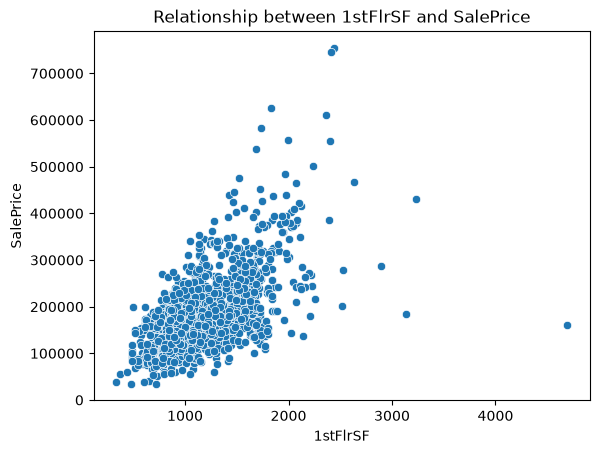

In [17]:
# Examine the relationship between 1stFlrSF and the target variable
sns.scatterplot(x = "1stFlrSF", y = target, data = train)
plt.title(f"Relationship between 1stFlrSF and {target}")
plt.show()

8. Generate 2 more scatter plots using the target column as your y-axis and a numeric column on the x-axis, such as "OverallQual", "YearBuilt", "FullBath", etc. 

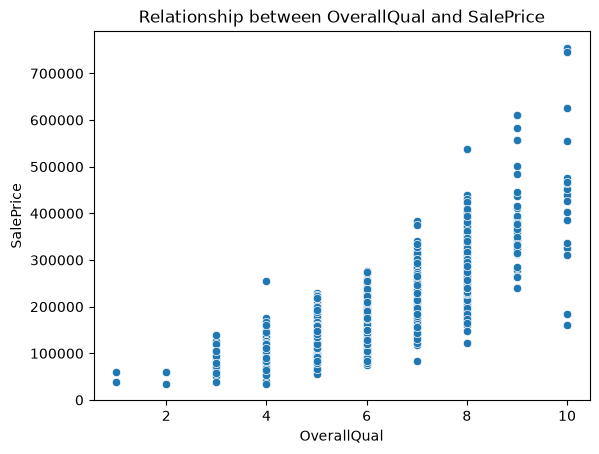

In [18]:
# Examine the relationship between OverallQual and the target variable
sns.scatterplot(x = "OverallQual", y = target, data = train)
plt.title(f"Relationship between OverallQual and {target}")
plt.show()

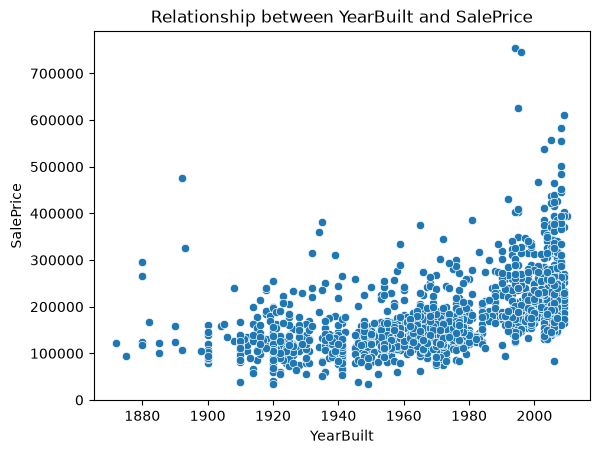

In [19]:
# Examine the relationship between YearBuilt and the target variable
sns.scatterplot(x = "YearBuilt", y = target, data = train)
plt.title(f"Relationship between YearBuilt and {target}")
plt.show()

Scatter plots are helpful for visualizing relationships between numeric variables, but when you are working with a large dataset like this one, it can become difficult to examine each numeric feature individually. Correlation can be used as a method for identifying features that are likely to be valuable for predictive modeling. Specifically, features that correlate well with the target (positively or negatively) often make strong candidates for features to keep. In this activity, the approach will be used to identify weak features to drop based on a low correlation with the target so that the remaining features can be explored further.

Note: It is possible for a strong feature to have low correlation with the target variable since correlation only measures the strenth of "linear" relationships. A feature may possess a strong "non-linear" relationship with the target and have low correlation which could be revealed in a scatter plot. For now, you'll focus on utilizing linear relationships for feature selection.

In pandas, the "corr" method is useful for generating a correlation matrix from a dataframe. A correlation matrix is essentially a cross tabulation where the values are the (Pearson) correlation coefficients of each combination of columns which range between -1 (perfect negative correlation) and +1 (perfect positive correlation). Values close to 0 indicate weak or no correlation. The correlation matrix itself is a dataframe and so it can be manipulated using the usual dataframe methods.

9. Complete the code in the following code cell to calculate the correlation between the numeric features listed in "num_cols" and the target variable, storing the result as "correlations". The appropriate columns are selected for you, it is your job to apply the "corr" method to generate the correlation matrix, select the target column, and sort the values in descending order by absolute value.

In [20]:
# Chain appropriate methods to calculate the correlation between numeric features
# and the target variable, and sort the values in descending order
correlations = train[num_cols + [target]].corr()[target].sort_values(key = abs, ascending=False)
print(correlations)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
ScreenPorch      0.111447
PoolArea         0.092404
OverallCond     -0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold          -0.028923
LowQualFinSF    -0.025606
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePrice, dtype: float64


10. Identify weak columns by filtering "correlations" for absolute values less than 0.3 and store the result in a list called "weak_num_cols".

In [21]:
# Filter the correlations to identify numeric features with weak correlation
weak_num_cols = correlations[correlations.abs() < 0.3].index.to_list()  
# Print the result
print(weak_num_cols)

['HalfBath', 'LotArea', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'KitchenAbvGr', 'EnclosedPorch', 'ScreenPorch', 'PoolArea', 'OverallCond', 'MoSold', '3SsnPorch', 'YrSold', 'LowQualFinSF', 'MiscVal', 'BsmtHalfBath', 'BsmtFinSF2']


Run the following code cell to add the weak numeric columns identified to the "drop_cols" list for tracking purposes. The weak numeric columns are also removed from the "num_cols" to simplify the remaining EDA steps.

In [22]:
# Add weak numeric columns to the list of columns to drop
drop_cols.extend(weak_num_cols)

# Remove the columns to drop from the list of numeric columns
num_cols = [col for col in num_cols if col not in drop_cols]

### Correlation Heatmaps

Now that you've looked at relationships between the numeric features and the target, it is a good time to look at the relationships between the numeric features themselves. Features that correlate strongly with each other ("multicollinearity") often contain similar information. This can indicate that there is some redundancy between features where you may be able to drop features while retaining most of the information that the model learns from. Many models aren't negatively affected by this multicollinearity other than having additional features, but linear models such as linear regression can become unstable if multicollinearity is present. A correlation heatmap of the numeric features is a useful visual tool for identifying multicollinearity.

11. In the following code cell, create correlation matrix called "corr_matrix" using remaining numeric features in the train dataframe only. To create a heatmap, use the correlation matrix as the first argument. The remaining arguments are set to use a diverging color palette so that strongly correlated features stand out (i.e., dark red or dark blue cells).

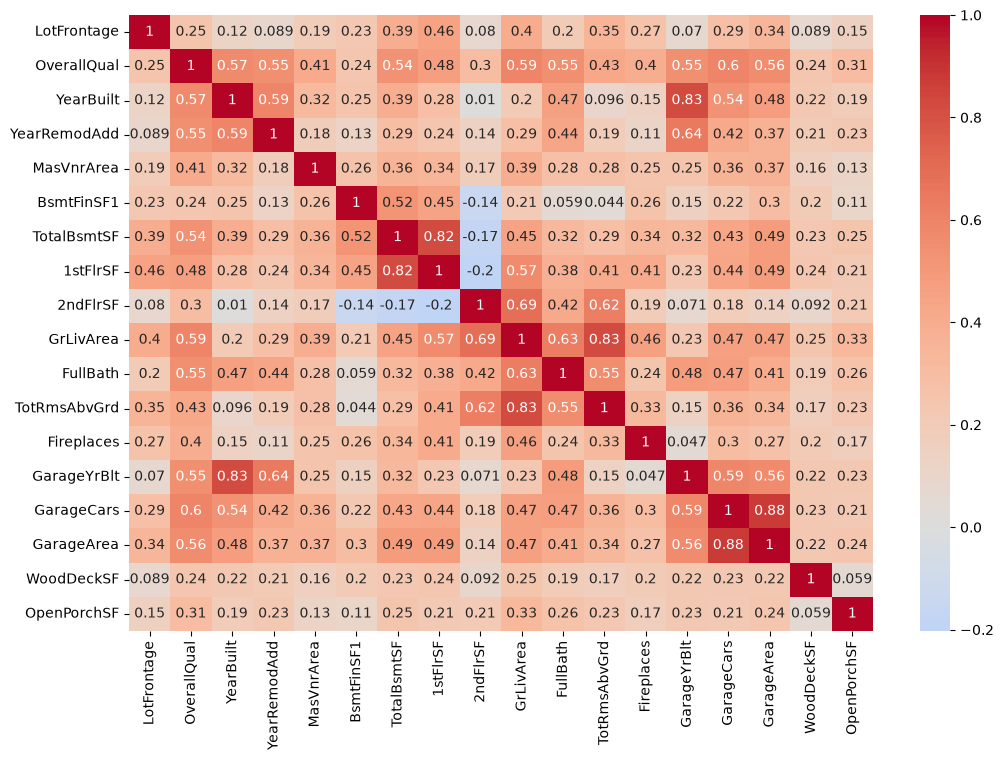

In [23]:
corr_matrix = train[num_cols].corr()

plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix,
    annot = True,
    cmap = "coolwarm",
    center = 0)
plt.show()

12. Identify all pairs of numeric features with correlation coefficients greater than 0.8. You can visually inspect the correlation heatmap above and list the pairs manually if you like, or you can try to extract this information from the correlation matrix ("corr_matrix") programmatically. Remember, the correlation matrix is just a pandas dataframe where the index (i.e., "row labels") are the same as the columns, so it can be maninpulated using the usual pandas methods.

Note: Each pair appears twice in the correlation matrix, but they should be treated as a single pair, i.e., the pair (col1, col2) is the same as (col2, col1) since the correlation matrix is symmetric.

In [24]:
# Extract pairs of numeric features with correlation > 0.8
# Mask the upper triangle so each pair is only counted once
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))
high_corr = upper.stack()
high_corr_pairs = high_corr[high_corr.abs() > 0.8]
print(high_corr_pairs)

YearBuilt    GarageYrBlt     0.825667
TotalBsmtSF  1stFlrSF        0.819530
GrLivArea    TotRmsAbvGrd    0.825489
GarageCars   GarageArea      0.882475
dtype: float64


13. Choose 1 feature from each pair to drop and add them to the "drop_cols" list. If 1 of your pairs contains "YearBuilt", drop the other feature in the pair instead as the "YearBuilt" feature will be used later in the feature engineering section.

In [25]:
# Add one column from each multicollinear pair of columns to
# the list of columns to drop
drop_cols.extend(["1stFlrSF", "TotRmsAbvGrd", "GarageArea", "GarageYrBlt"])

# Remove the columns to drop from the list of numeric columns
num_cols = [col for col in num_cols if col not in drop_cols]

## Categorical Features

The usual discrete plots (i.e., bar plots, count plots, cross tabulations, etc.) and summary statistics are useful when exploring categorical feature individually or in pairs. When preparing categorical features for regression models, distributions of the target variable by feature categories are a powerful tool for identifying strong features. Box plot or violinplots are valuable here and can be used in a similar fashion to how numeric features are examined in classification problems, the only difference is that the features are now categorical and target is numeric so the roles are reversed.

To start this section, you'll look for "easy" candidates for categorical features to drop so that you can focus your efforts on finding strong features later.

14. Use an appropriate method to count the number of unique values in each categorical column. Sort the result in descending order by cardinality so that the highest cardinality columns appear first.

In [26]:
# Check the number of unique values in each categorical column
train[cat_cols].nunique().sort_values(ascending=False)

Id               1460
Neighborhood       25
Exterior2nd        16
Exterior1st        15
MSSubClass         15
SaleType            9
Condition1          9
Condition2          8
HouseStyle          8
RoofMatl            8
BsmtFinType2        7
GarageType          7
BsmtFinType1        7
Functional          7
Foundation          6
GarageCond          6
SaleCondition       6
GarageQual          6
Heating             6
RoofStyle           6
ExterCond           5
MSZoning            5
LotConfig           5
HeatingQC           5
BsmtExposure        5
Electrical          5
BsmtCond            5
BsmtQual            5
BldgType            5
LotShape            4
LandContour         4
GarageFinish        4
KitchenQual         4
ExterQual           4
LandSlope           3
PavedDrive          3
Street              2
Utilities           2
CentralAir          2
dtype: int64

Compare the counts of unique values in each column to the total number of rows in the dataframe. As a reminder, "ID" columns usually don't contain useful information (they are essentially just row labels here) for the purpose of predictive modeling and an easy way to detect them is look at high cardinality columns. With that in mind, high cardinality by itself doesn't mean a feature is weak and subject matter expertise is often required to decide how to handle these columns.

15. Based on your results from the previous code cell, choose 1 feature to drop and add it to the "drop_cols" list in the next code cell using an appropriate method.

In [27]:
# Add columns to drop list that are no longer needed for modeling
drop_cols.extend(["Id"])

Features with low or no variation often contribute little information for the purpose of predictive modeling. For categorical features, this usually appears as features where a single category comprises a vast majority of the values. In the extreme case where all the values come from a single category, the feature is useless and should be dropped. In less extreme cases, the decision will depend on how imbalanced a feature's distribution is and subject matter expertise. Here you will use this approach to identify which features to drop based on the value counts of each category.

16. In the next code cell complete the "lambda" function in the "apply" method so that the value_counts method is applied to each categorical column denoted by "x". Ensure that "normalize" is set to "True" and ascending is set to False in the value_counts method. This will convert the value counts for each column into percentages for each category and sort them so that the most frequent category appears first. "iloc[0] * 100" selects the top category for each feature and converts the proportion to a percentage. This returns a pandas series, so the next line of code converts this to a dataframe. Lastly, sort the "imb_summary_df" dataframe in descending order by the "Top %" column so that the most imbalanced features appear first.

In [28]:
# Identify the top categorical value for each categorical feature and the 
# percentage of rows with that value
imb_summary = train[cat_cols].apply(lambda x: x.value_counts(normalize=True, ascending=False).iloc[0] * 100)
# Convert the Series to a DataFrame and reset the index to have "Feature"
# as a column
imb_summary_df = imb_summary.to_frame(name = "Top %").reset_index(names = "Feature")

# Sort the DataFrame by the "Top %" column in descending order
imb_summary_df = imb_summary_df.sort_values(by="Top %", ascending=False)

17. For this activity, treat any categorical features where the top category accounts for greater than 94% of the rows as weak features that should be dropped. Based on the results from the previous code cell, add all features that meet this criteria to the "drop_cols" list in the next code cell. These columns will also be removed from the list of "cat_cols" for the remaining EDA.

In [29]:
# Add imbalanced categorical columns to the list of columns to drop
imbalanced_cols = imb_summary_df[imb_summary_df["Top %"] > 94]["Feature"].to_list()
drop_cols.extend(imbalanced_cols)
print(imbalanced_cols)


# Remove the columns to drop from the list of categorical columns
cat_cols = [col for col in cat_cols if col not in drop_cols]

['Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating', 'LandSlope']


You likely still have a large number of categorical features in your dataset. It is possible that you could fit a regression model with all remaining categorical features intact, but your model will almost certainly be more complex than is needed and predictions will be difficult to explain. Domain knowledge can be very valuable when it comes to choosing features that have strong predictive power and are meaningful. You may not be an expert in housing (or maybe you are), but you can probably think of features that you would associate with the price of a house. As such, the next step of this activity will be to examine the remaining categorical features in "cat_cols" and select 10 to 15 of them that you think would be associated with sales prices, then examine each further using box plots to validate your choices or eliminate some from consideration.

18. Print the list of remaining categorical columns in "cat_cols" to see which categorical features remain.

In [30]:
print(cat_cols)

['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition', 'MSSubClass']


19. Pick 10-15 of the remaining categorical columns and store their names in the "select_cat_cols" list in the next code cell. Hint: You can copy the output from the previous code cell and remove the columns you don't want to keep to avoid having to type all the names manually.

In [31]:
# Select categorical columns you think might be important for analysis
select_cat_cols = ["MSZoning", "Neighborhood", "BldgType", "HouseStyle",
                   "ExterQual", "Foundation", "BsmtQual", "HeatingQC",
                   "CentralAir", "KitchenQual", "GarageType", "GarageFinish"]

20. Generate a box plot for each column you selected with the target column. You can loop over the column names in "select_cat_cols" to generate each plot to avoid copying the plotting code 10-15 times.

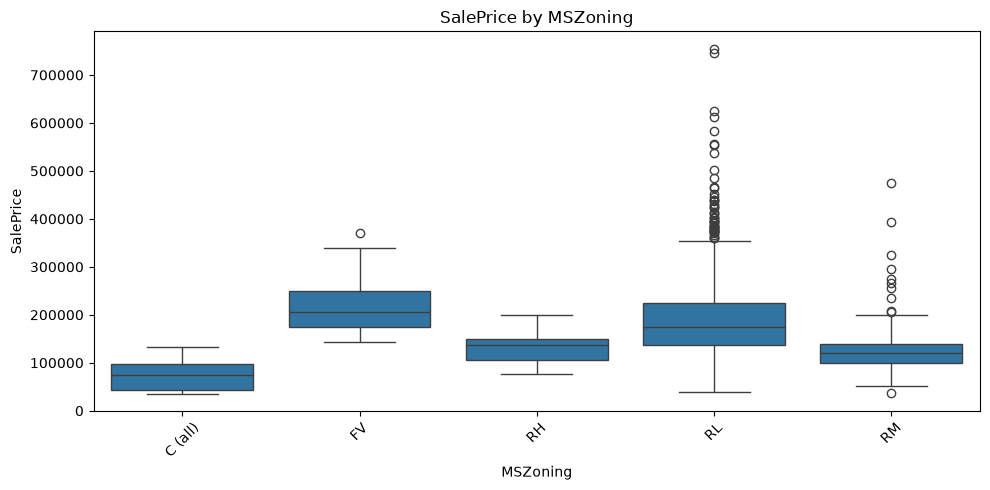

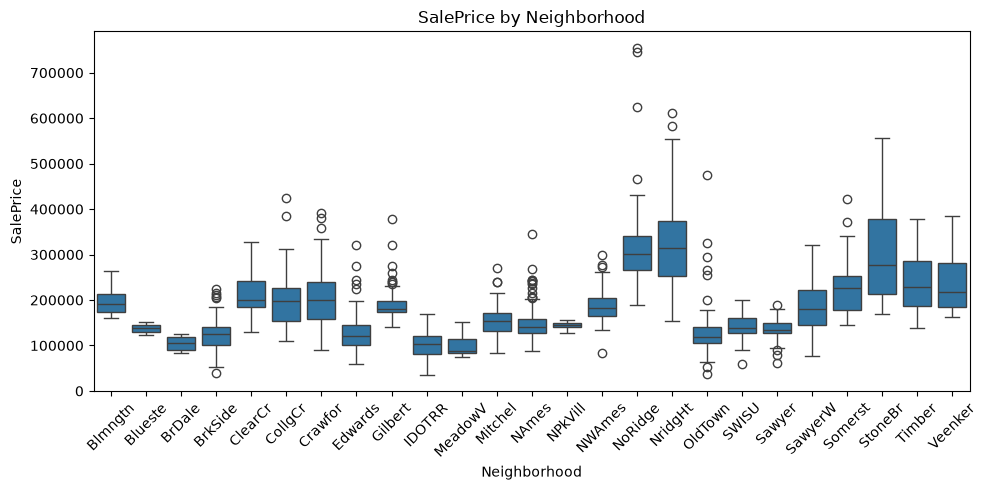

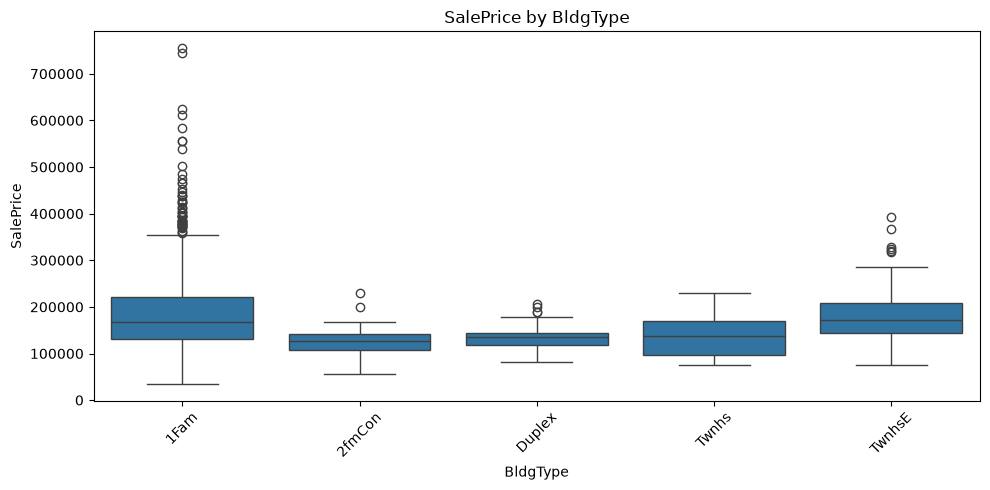

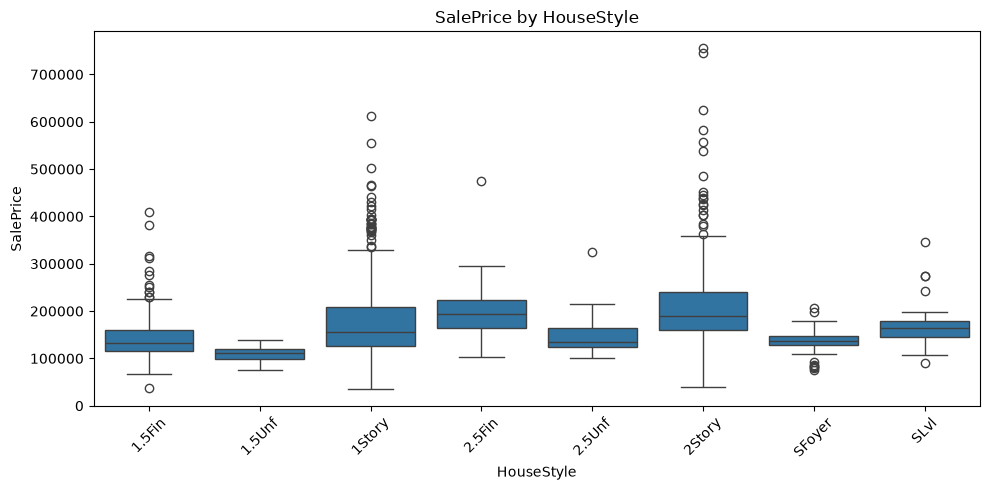

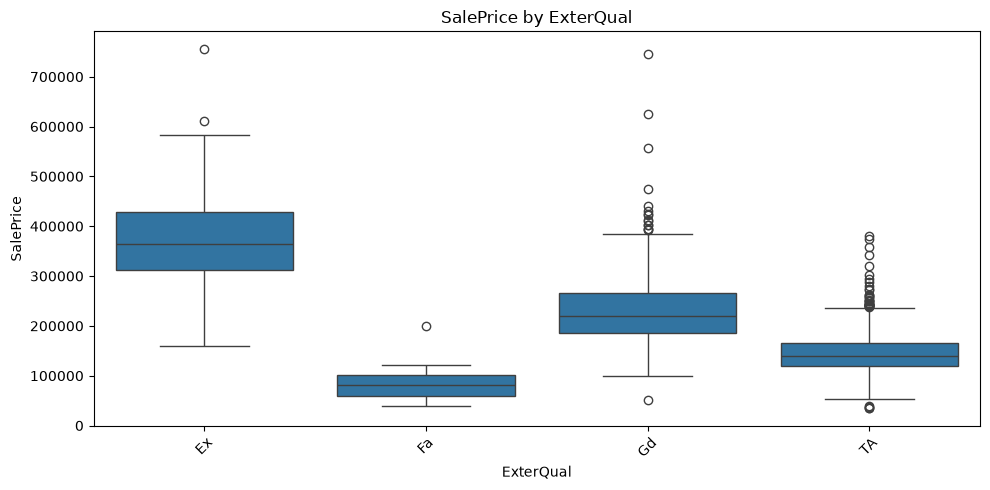

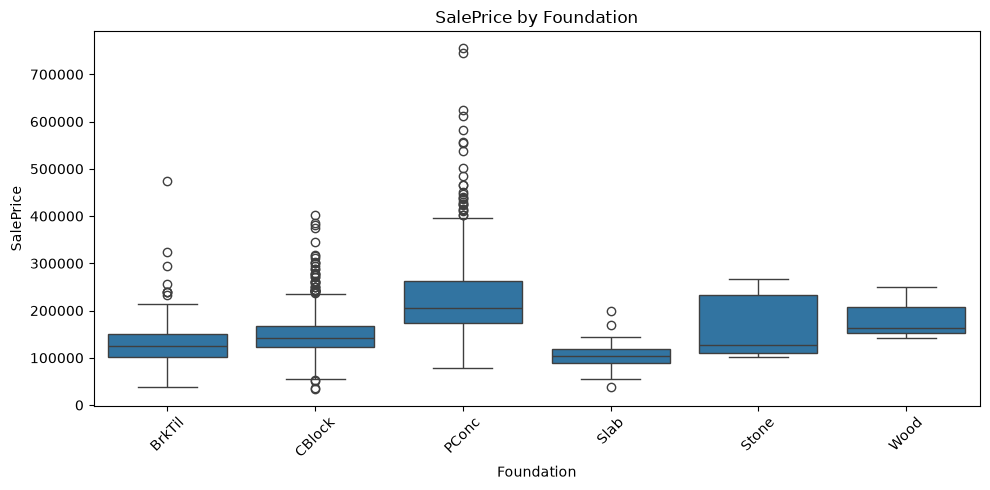

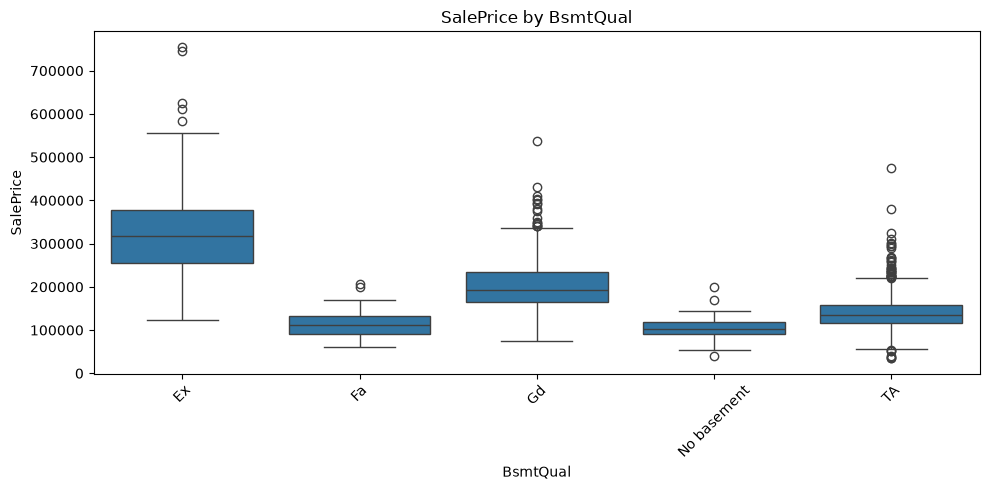

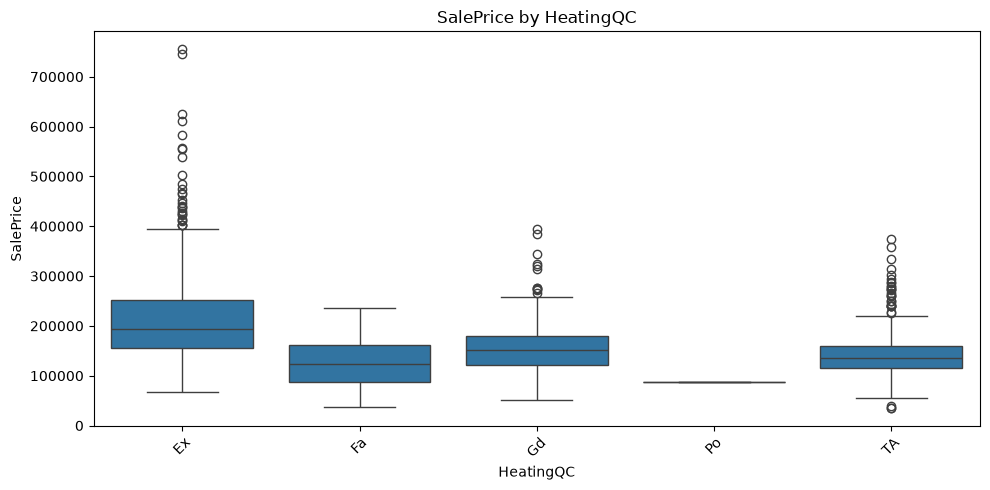

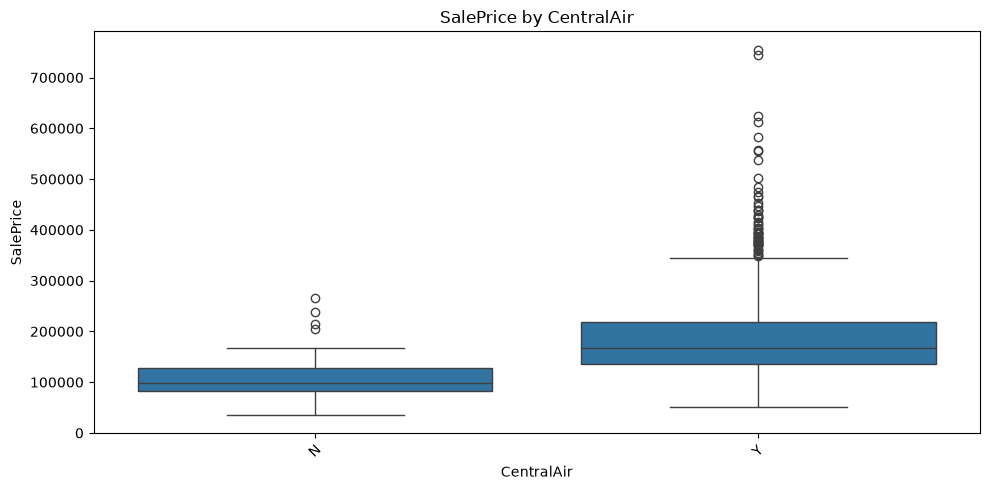

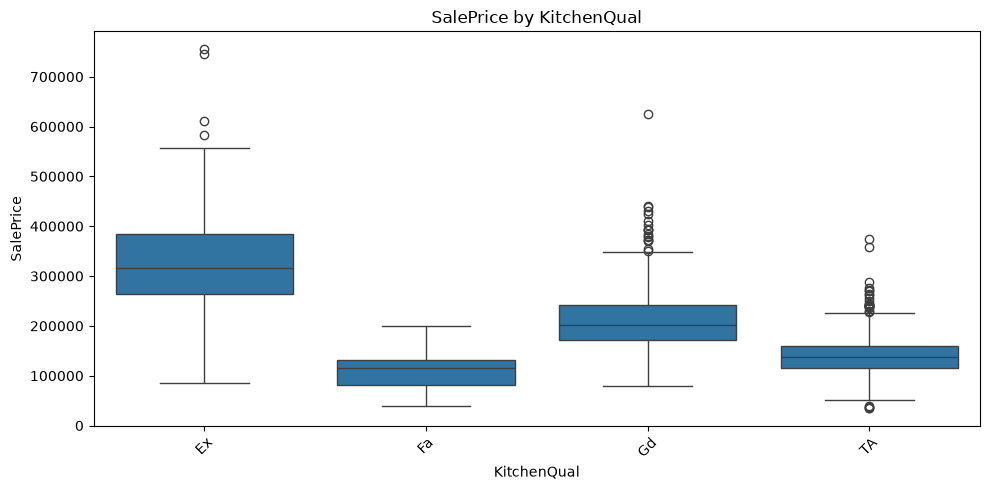

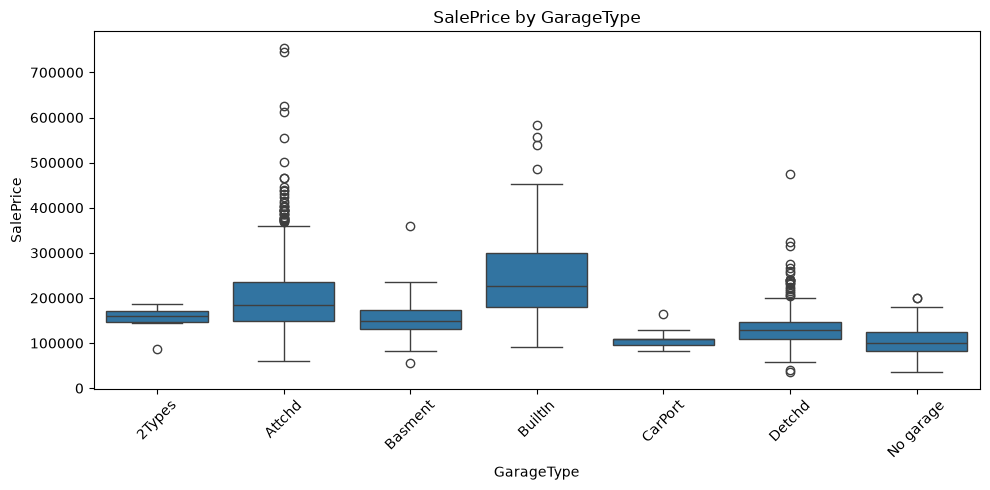

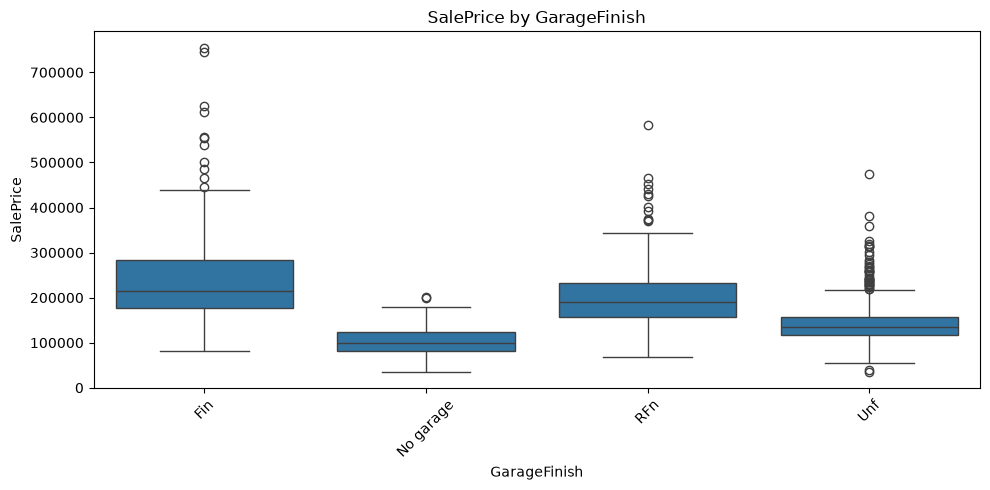

In [32]:
# Generate boxplots for each selected categorical column against 
# the target variable
for col in select_cat_cols:
    plt.figure(figsize = (10, 5))
    sns.boxplot(x = col, y = target, data = train)
    plt.title(f"{target} by {col}")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()






Take some time to examine each box plot you generated. The general guidance here is to keep features where the boxes for each category appear separated from each other which implies that the category is an important factor in the determining the value of the target variable. Weak features tend to be those where the boxes appear to be very similar across categories because a similar sales prices would be expected regardless of the category.

21. Refine your list of selected categorical columns in the "select_cat_cols_refined" list below based on your findings from the box plots. You may find that all the features you picked show strong separation across categories, in which case you can keep all the features you selected and copy the same list you used for "select_cat_cols". If you identified some weak features, leave them out of your refined list. If every feature you selected appears weak, repeat the previous two steps using different features in your "select_cat_cols" list and generate the box plots again.

In [33]:
# Refine your list of selected categorical columns based on the boxplots 
# and your analysis
select_cat_cols_refined = ["MSZoning", "Neighborhood", "ExterQual", "Foundation",
                           "BsmtQual", "HeatingQC", "CentralAir", "KitchenQual",
                           "GarageType", "GarageFinish"]

Run the next code cell to update your "cat_cols" and "drop_cols" lists based on your selections from the previous code cell.

In [34]:
# Store a list of column not selected in the previous step
drop_cat_cols = [col for col in cat_cols if col not in select_cat_cols_refined]

# Store your selected columns back in cat_cols for further analysis and modeling
cat_cols = select_cat_cols_refined.copy()

# Add categorical columns not selected to the list of columns to drop
drop_cols.extend(drop_cat_cols)

# Feature Engineering

In the following exercise, you will practice feature engineering by creating a "HouseAge" feature. The "YearBuilt" and "YrSold" features in the dataset represent the year the house was built and year the house was sold, respectively. The "HouseAge" feature can be created by calculating the difference between these two existing features. Note that "HouseAge" is meant to represent the age of the house at the time it was sold so that the "SalePrice" is the price the house was sold for when the house was "HouseAge" years old.

22. In the following code cell, complete the code to create the new "HouseAge" feature in the train dataframe.

In [35]:
# Calculate house age from year sold and year built
train['HouseAge'] = train['YrSold'] - train['YearBuilt']

One common objective of feature engineering is to create a new feature which captures similar information as several existing features. In this case, the new feature would replace the existing features from which it was derived, allowing for a simpler model to be trained. It is almost always preferable to train a model which requires fewer features so long as the performance doesn't suffer significantly. In the example above, one new feature was created by combining two existing features. As such, there is some redundancy between these three features which can be resolved by dropping two of them.

23. In the next code cell, add the features that are no longer needed as a result of the feature engineering you performed to the "drop_cols" list for tracking purposes. These features won't be used for model training and will be dropped later. The new "HouseAge" feature will be added to your "num_cols" list.

In [36]:
# Add columns to drop list that are no longer needed for modeling
drop_cols.extend(["YearBuilt", "YrSold"])

# Add the engineered column to the list of numeric columns
num_cols.extend(["HouseAge"])


# Remove the columns to drop from the list of numeric columns
num_cols = [col for col in num_cols if col not in drop_cols]

# Feature Selection

The last exercise for this assignment involves selecting the features to keep for training regression models in the next assignment. The selected features shouldn't include the target column or any features you chose to drop in the "drop_cols" list. Note: In practice, you would usually either drop the columns you don't want to keep or select the columns you do want to keep, as the result is essentially the same in both. Your "drop_cols" list is sorted and printed below for reference.

In [37]:
# View a sorted list of columns to drop
print(sorted(drop_cols))

['1stFlrSF', '3SsnPorch', 'Alley', 'BedroomAbvGr', 'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF2', 'BsmtFinType1', 'BsmtFinType2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'Condition1', 'Condition2', 'Electrical', 'EnclosedPorch', 'ExterCond', 'Exterior1st', 'Exterior2nd', 'Fence', 'FireplaceQu', 'Functional', 'GarageArea', 'GarageCond', 'GarageQual', 'GarageYrBlt', 'HalfBath', 'Heating', 'HouseStyle', 'Id', 'KitchenAbvGr', 'LandContour', 'LandSlope', 'LotArea', 'LotConfig', 'LotShape', 'LowQualFinSF', 'MSSubClass', 'MasVnrType', 'MiscFeature', 'MiscVal', 'MoSold', 'OverallCond', 'PavedDrive', 'PoolArea', 'PoolQC', 'RoofMatl', 'RoofStyle', 'SaleCondition', 'SaleType', 'ScreenPorch', 'Street', 'TotRmsAbvGrd', 'Utilities', 'YearBuilt', 'YrSold', 'YrSold']


You already identified the name of the target column which is printed below for reference.

In [38]:
# Print the target name
print(target)

SalePrice


24. Identify all columns that you are planning to keep in the "select_cols" list below. This should include all features from the "num_cols" and "cat_cols" lists, so you just need to combine these two lists.

In [39]:
# Final features selected for modeling
select_cols = num_cols + select_cat_cols_refined

# Print the selected features for reference
print(select_cols)

['LotFrontage', 'OverallQual', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '2ndFlrSF', 'GrLivArea', 'FullBath', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'HouseAge', 'MSZoning', 'Neighborhood', 'ExterQual', 'Foundation', 'BsmtQual', 'HeatingQC', 'CentralAir', 'KitchenQual', 'GarageType', 'GarageFinish']


For the last step, the features and the target will be separated in prepartion for model training. A common convention is to store features in a variable called "X_train" and the target in a variable called "y_train".

25. Select the columns from the "train" dataframe that you want to use as features and store them in the "X_train" variable below. Select the target column from the "train" dataframe and store it in the "y_train" variable below. Print the first rows to inspect the final dataset.

In [40]:
# Define the features (X) and target (y) for modeling
X_train = train[select_cols]
y_train = train[target]

# Display the first few rows of the features and target
print("Features:")
print(X_train.head())
print("Target:")
print(y_train.head())

Features:
   LotFrontage  OverallQual  YearRemodAdd  MasVnrArea  BsmtFinSF1  \
0         65.0            7          2003       196.0         706   
1         80.0            6          1976         0.0         978   
2         68.0            7          2002       162.0         486   
3         60.0            7          1970         0.0         216   
4         84.0            8          2000       350.0         655   

   TotalBsmtSF  2ndFlrSF  GrLivArea  FullBath  Fireplaces  ...  MSZoning  \
0          856       854       1710         2           0  ...        RL   
1         1262         0       1262         2           1  ...        RL   
2          920       866       1786         2           1  ...        RL   
3          756       756       1717         1           1  ...        RL   
4         1145      1053       2198         2           1  ...        RL   

   Neighborhood  ExterQual  Foundation BsmtQual HeatingQC CentralAir  \
0       CollgCr         Gd       PConc       G

26. In the following empty markdown cell, briefly summarize your reasons for choosing the features you selected in "select_cols". You may wish to discuss your reasons for dropping features that weren't included in "select_cols" to support your selections. If several features were selected/dropped for the same reason, you can discuss them as a group of features rather than individually to avoid repetition. Note: Given that this dataset contained 80 candidate features initially, you don't need to describe each individual feature here, and you should focus on groups of features with similar characteristics in your response.

## Feature Selection Summary

I kept features that either correlate strongly with SalePrice or separate it clearly by category: size and quality measures (living area, basement area, garage capacity, overall quality, engineered HouseAge), quality ratings (ExterQual, BsmtQual, KitchenQual, HeatingQC), and location/structure (Neighborhood, MSZoning, Foundation, CentralAir, GarageType, GarageFinish).

I dropped the rest for a few reasons. Garage and basement NAs meant "no garage/basement," not missing data, so I filled those instead of dropping them. Six features (PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu) were still over 40% missing and too sparse to use. Numeric features correlating below 0.3 with SalePrice were dropped as weak, and one column from each highly correlated pair (TotalBsmtSF/1stFlrSF, GrLivArea/TotRmsAbvGrd, GarageCars/GarageArea, YearBuilt/GarageYrBlt) was dropped to reduce redundancy. Categorical features where one category held over 94% of rows, plus Id, were dropped for near-zero variance. BldgType and HouseStyle were dropped after box plots showed heavy overlap between categories. Finally, YearBuilt and YrSold were replaced by the engineered HouseAge feature.